In [1]:
import torch
import torch.nn as nn
from tqdm.auto import tqdm

from torchvision.utils import make_grid



import numpy as np
import os
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import models, transforms, datasets

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

data_dir = "/kaggle/input/pix2pix-maps"

data_transform = transforms.Compose([
    transforms.Resize((256, 512)),
    transforms.CenterCrop((256, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Custom Dataset mimicking ImageFolder without class subdirectories
class CustomImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        # Collect all image file paths in the root directory
        self.image_paths = [
            os.path.join(root, fname)
            for fname in os.listdir(root)
            if os.path.isfile(os.path.join(root, fname)) and fname.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

# Create datasets and dataloaders
dataset_train = CustomImageDataset(root=os.path.join(data_dir, "train"), transform=data_transform)
dataset_val = CustomImageDataset(root=os.path.join(data_dir, "val"), transform=data_transform)

dataloader_train = DataLoader(dataset_train, batch_size=24, shuffle=True, num_workers=4)



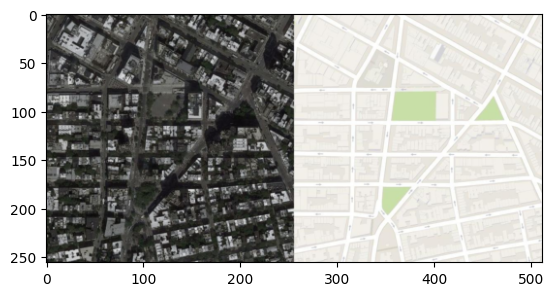

In [3]:
Normalization_Values = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

def DeNormalize(tensor_of_image):
    # Apply de-normalization
    mean = Normalization_Values[0]
    std = Normalization_Values[1]
    return tensor_of_image * std[0] + mean[0
]
images= next(iter(dataloader_train))

for image in images:  
  plt.imshow(DeNormalize(image).permute(1,2,0))
  plt.show()
  break;

In [4]:

def print_images(image_tensor, num_images):
    
    images = DeNormalize(image_tensor)
    images = images.detach().cpu()
    image_grid = make_grid(images[:num_images], nrow=5)
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())
    plt.show()

In [5]:

class DownSample(nn.Module):
    def __init__(self, Input_Channels, Output_Channels):
        super(DownSample, self).__init__()
        # nn.Conv2d(in_channel, out_channel, kernel, stride, padding)
        self.model = nn.Sequential(
                     nn.Conv2d(Input_Channels, Output_Channels, 4, 2, 1, bias=False),
                     nn.LeakyReLU(0.2)
                     )

    def forward(self, x):
        down = self.model(x)
        return down


class Upsample(nn.Module):
    def __init__(self, Input_Channels, Output_Channels):
        super(Upsample, self).__init__()
        
        self.model = nn.Sequential( 
                     nn.ConvTranspose2d(Input_Channels, Output_Channels, 4, 2, 1, bias=False),
                     nn.InstanceNorm2d(Output_Channels),
                     nn.ReLU(inplace=True),)

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x


class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(Generator, self).__init__()

        self.down1 = DownSample(in_channels, 64)
        self.down2 = DownSample(64, 128)
        self.down3 = DownSample(128, 256)
        self.down4 = DownSample(256, 512)
        self.down5 = DownSample(512, 512)
        self.down6 = DownSample(512, 512)
        self.down7 = DownSample(512, 512)
        self.down8 = DownSample(512, 512)

        self.up1 = Upsample(512, 512)
        self.up2 = Upsample(1024, 512)
        self.up3 = Upsample(1024, 512)
        self.up4 = Upsample(1024, 512)
        self.up5 = Upsample(1024, 256)
        self.up6 = Upsample(512, 128)
        self.up7 = Upsample(256, 64)

        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, 3, 4, padding=1), # out_channels
            nn.Tanh(),
        )

    def forward(self, x):
        # U-Net generator with skip connections from encoder to decoder

        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)
        u1 = self.up1(d8, d7)
        u2 = self.up2(u1, d6)
        u3 = self.up3(u2, d5)
        u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3)
        u6 = self.up6(u5, d2)
        u7 = self.up7(u6, d1)
        u8 = self.final(u7)
        return u8

In [6]:


# Building Discriminator

class Discriminator(nn.Module):
    def __init__(self, in_channels=3,):
        super(Discriminator, self).__init__()

        
        self.model = nn.Sequential(
                     nn.Conv2d(6, 64, 4, 2, 1, bias=False),
                     nn.LeakyReLU(0.2, inplace=True),

                     nn.Conv2d(64, 128, 4, 2, 1, bias=False),
                     nn.LeakyReLU(0.2, inplace=True),

                     nn.Conv2d(128, 256, 4, 2, 1, bias=False),
                     nn.LeakyReLU(0.2, inplace=True),

                     nn.Conv2d(256, 512, 4, 2, 1, bias=False),
                     nn.LeakyReLU(0.2, inplace=True),

                     nn.ZeroPad2d((1, 0, 1, 0)),
                     nn.Conv2d(512, 1, 4, padding=1, bias=False)
                     
                     )

        
    def forward(self, img_A, img_B):
        # Here we are concatenating the images on their channels
        img_input = torch.cat((img_A, img_B), 1)
        return self.model(img_input)

In [7]:
def discriminator_training(inputs,targets,discriminator_opt):     

        discriminator_opt.zero_grad()
        
       
        # Passing real image and getting loss
        
        output = discriminator(inputs, targets) 
        label = torch.ones(size = output.shape, dtype=torch.float, device=device)
        
        real_loss = loss_comparison(output, label) 
        
        # Passing Generated image and getting loss
        
        gen_image = generator(inputs).detach()
         
        fake_output = discriminator(inputs, gen_image)
        fake_label = torch.zeros(size = fake_output.shape, dtype=torch.float, device=device) 
        
        fake_loss = loss_comparison(fake_output, fake_label)

        Total_loss = (real_loss + fake_loss)/2

        Total_loss.backward()
        
        discriminator_opt.step()

        return Total_loss

In [8]:
def generator_training(inputs,targets, generator_opt, L1_lambda):
          
            generator_opt.zero_grad()
            
            generated_image = generator(inputs)
            
            disc_output = discriminator(inputs, generated_image)
            desired_output = torch.ones(size = disc_output.shape, dtype=torch.float, device=device)
            
            generator_loss = loss_comparison(disc_output, desired_output) + L1_lambda * torch.abs(generated_image-targets).sum()
            generator_loss.backward()
            generator_opt.step()

            return generator_loss, generated_image

In [9]:

image = torch.rand((1,3,256,256))
out_channels = 3
generator = Generator()
k = generator(image)
print(k.shape)
image1 = torch.rand((1,3,256,256))
image2 = torch.rand((1,3,256,256))

out_channels = 3
discriminator = Discriminator()
k = discriminator(image1,image2)
print(k.shape)
     

torch.Size([1, 3, 256, 256])
torch.Size([1, 1, 16, 16])


In [10]:


L1_lambda = 100
NUM_EPOCHS= 100
lr=0.0002 
beta1=0.5
beta2=0.999
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


loss_comparison = nn.BCEWithLogitsLoss() 
L1_loss = nn.L1Loss()

discriminator_opt = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, beta2))
generator_opt = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))

discriminator = discriminator.to(device)
generator = generator.to(device)

Training epoch 1


  0%|          | 0/46 [00:00<?, ?it/s]

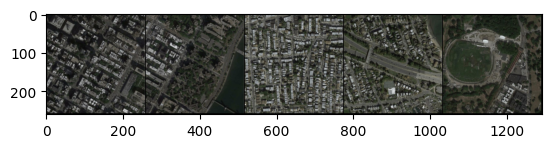

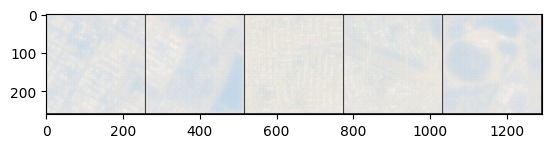

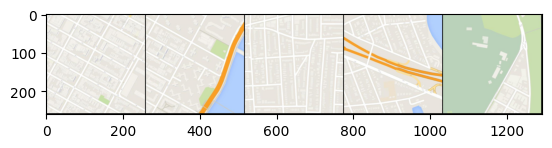

Training epoch 2


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 3


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 4


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 5


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 6


  0%|          | 0/46 [00:00<?, ?it/s]

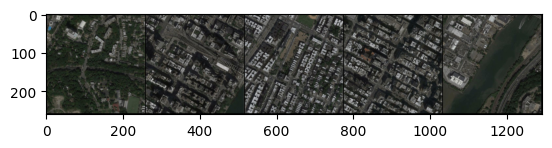

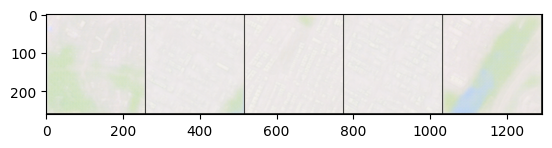

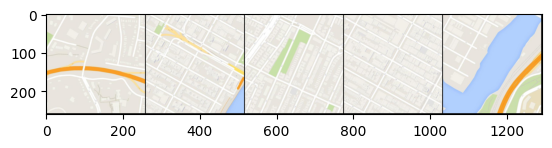

Training epoch 7


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 8


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 9


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 10


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 11


  0%|          | 0/46 [00:00<?, ?it/s]

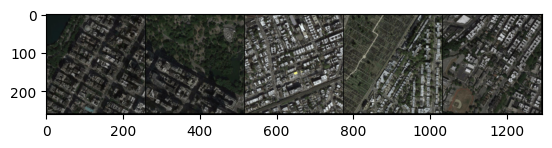

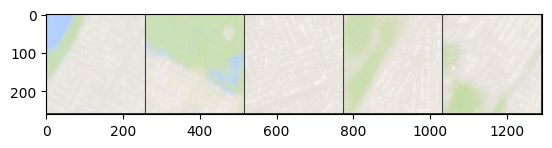

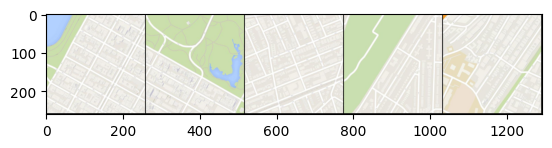

Training epoch 12


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 13


  0%|          | 0/46 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b42883a1b40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


...

  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 15


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 16


  0%|          | 0/46 [00:00<?, ?it/s]

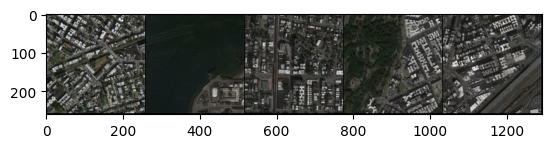

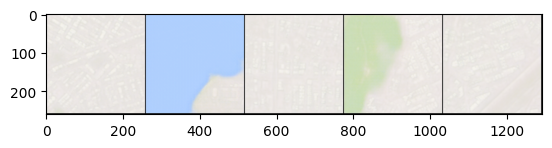

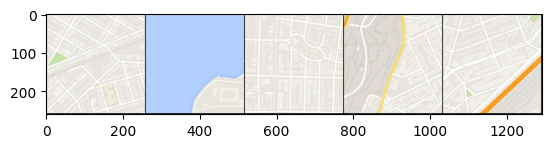

Training epoch 17


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 18


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 19


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 20


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 21


  0%|          | 0/46 [00:00<?, ?it/s]

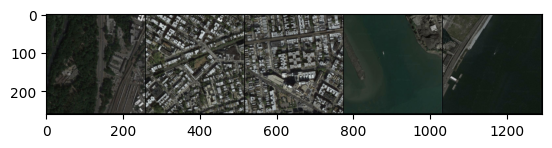

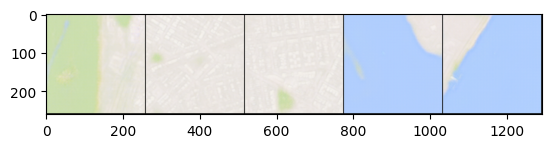

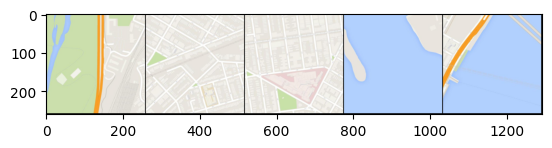

Training epoch 22


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 23


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 24


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 25


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 26


  0%|          | 0/46 [00:00<?, ?it/s]

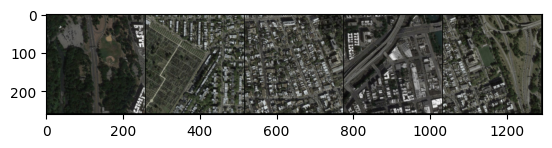

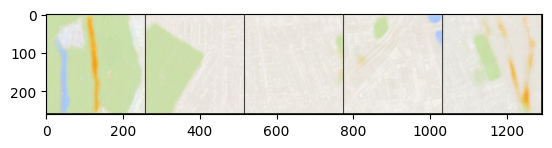

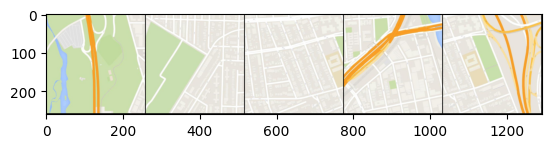

Training epoch 27


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 28


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 29


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 30


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 31


  0%|          | 0/46 [00:00<?, ?it/s]

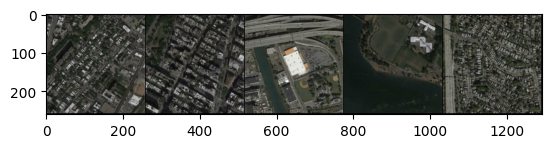

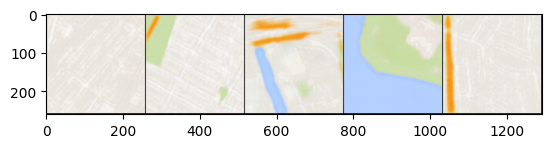

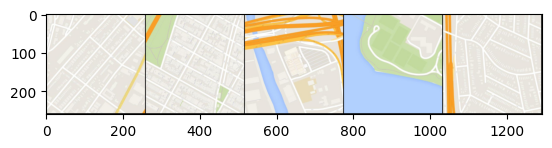

Training epoch 32


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 33


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 34


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 35


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 36


  0%|          | 0/46 [00:00<?, ?it/s]

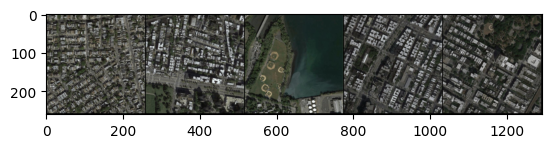

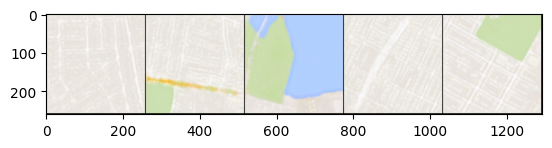

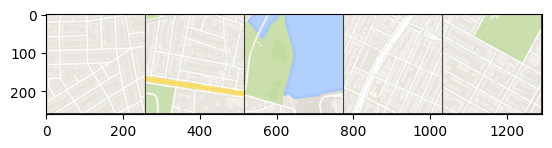

Training epoch 37


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 38


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 39


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 40


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 41


  0%|          | 0/46 [00:00<?, ?it/s]

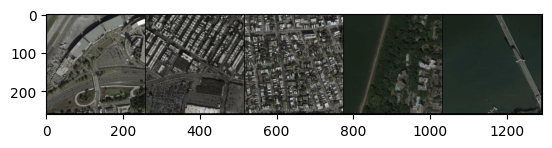

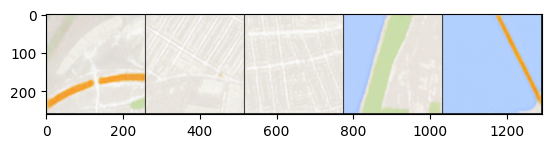

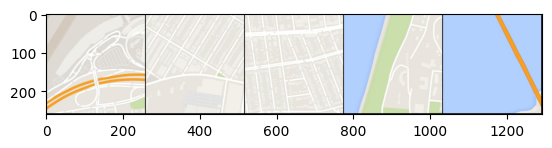

Training epoch 42


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 43


  0%|          | 0/46 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b42883a1b40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


...

  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 45


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 46


  0%|          | 0/46 [00:00<?, ?it/s]

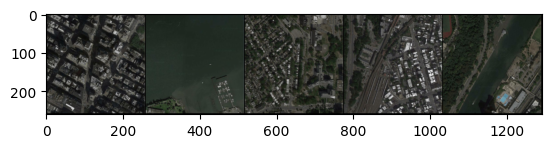

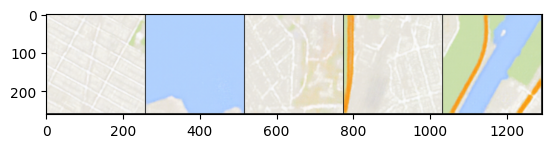

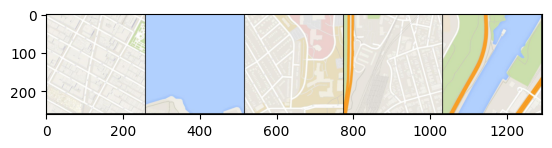

Training epoch 47


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 48


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 49


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 50


  0%|          | 0/46 [01:00<?, ?it/s]

Training epoch 51


  0%|          | 0/46 [00:00<?, ?it/s]

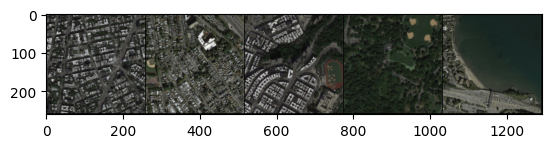

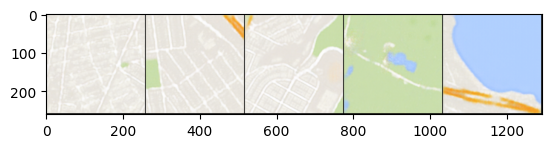

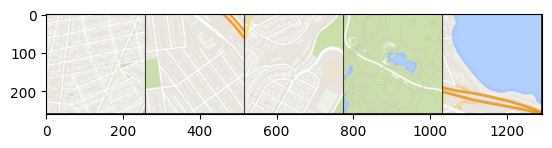

Training epoch 52


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 53


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 54


...

Training epoch 55


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 56


  0%|          | 0/46 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b42883a1b40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b42883a1b40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

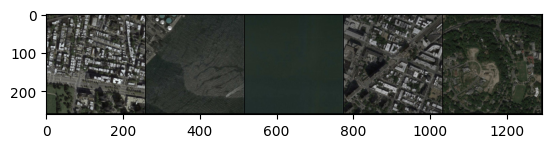

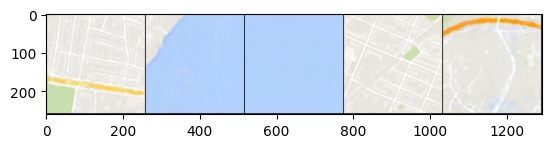

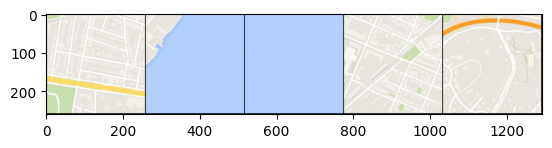

Training epoch 57


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 58


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 59


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 60


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 61


  0%|          | 0/46 [00:00<?, ?it/s]

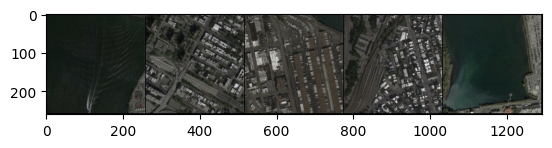

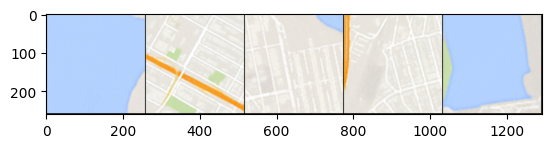

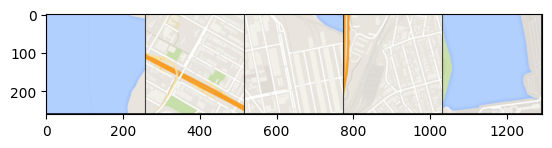

Training epoch 62


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 63


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 64


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 65


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 66


  0%|          | 0/46 [00:00<?, ?it/s]

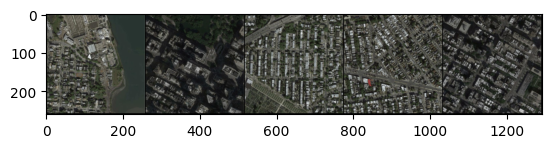

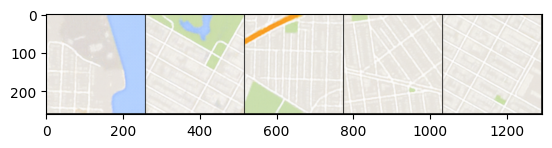

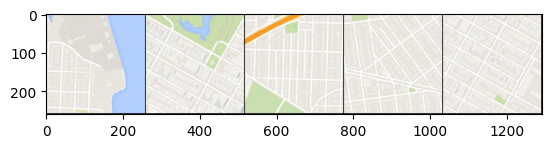

Training epoch 67


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 68


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 69


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 70


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 71


  0%|          | 0/46 [00:00<?, ?it/s]

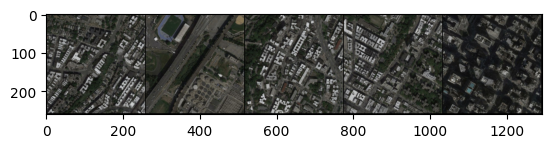

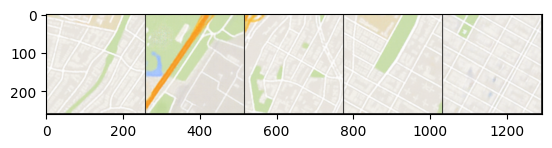

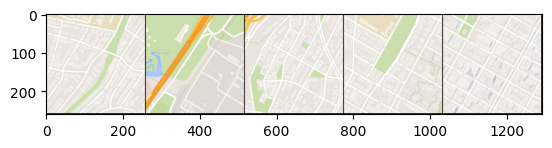

Training epoch 72


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 73


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 74


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 75


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 76


  0%|          | 0/46 [00:00<?, ?it/s]

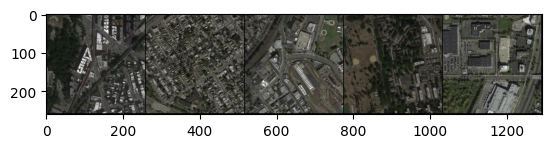

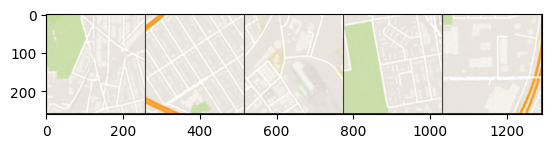

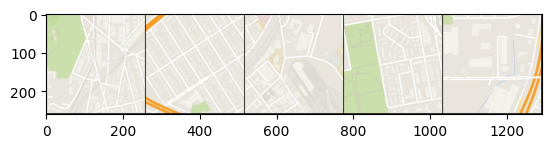

Training epoch 77


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 78


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 79


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 80


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 81


  0%|          | 0/46 [00:00<?, ?it/s]

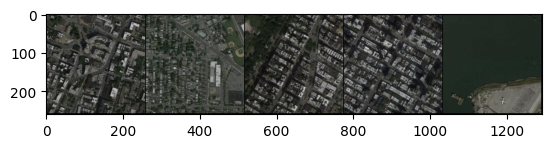

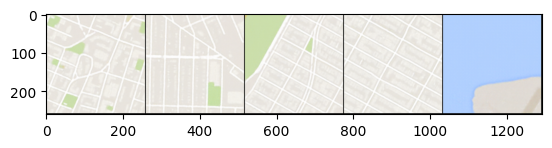

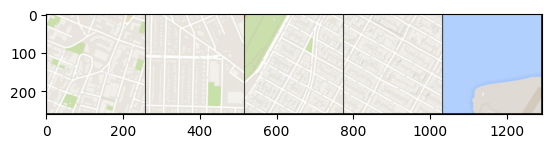

Training epoch 82


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 83


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 84


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 85


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 86


  0%|          | 0/46 [00:00<?, ?it/s]

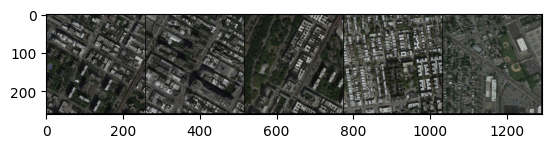

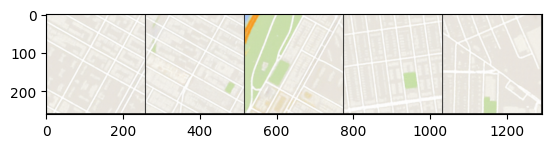

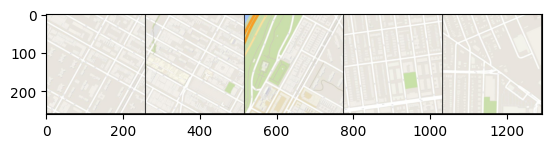

Training epoch 87


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 88


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 89


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 90


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 91


  0%|          | 0/46 [00:00<?, ?it/s]

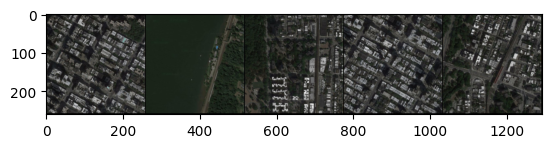

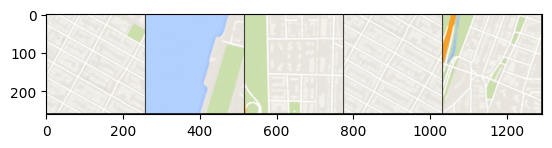

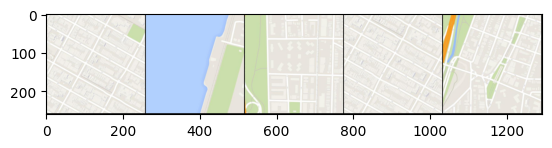

Training epoch 92


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 93


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 94


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 95


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 96


  0%|          | 0/46 [00:00<?, ?it/s]

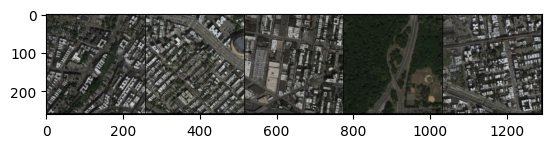

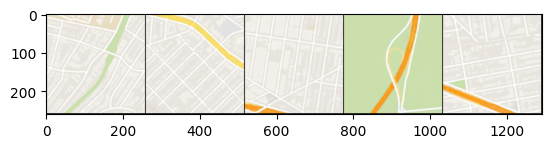

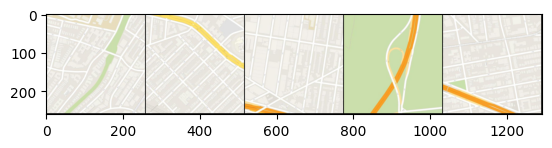

Training epoch 97


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 98


  0%|          | 0/46 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b42883a1b40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


...

  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 100


  0%|          | 0/46 [00:00<?, ?it/s]

Training epoch 101


  0%|          | 0/46 [00:00<?, ?it/s]

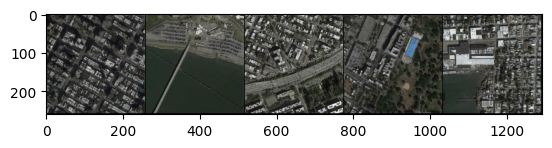

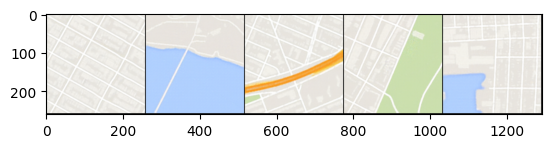

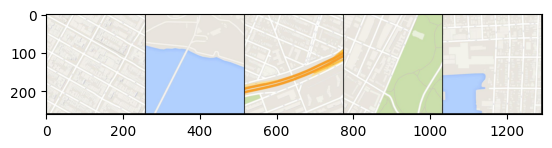

In [11]:

for epoch in range(NUM_EPOCHS+1):
    print(f"Training epoch {epoch+1}")
    for images in tqdm(dataloader_train):
       # Splitting the image 

       inputs = images[:,:,:,:256].to(device)
       targets = images[:,:,:,256:].to(device)

       # Train Discriminator

       Disc_Loss = discriminator_training(inputs,targets,discriminator_opt)

       # Train Geneerator
       for i in range(2):
            Gen_Loss, generator_image = generator_training(inputs,targets, generator_opt, L1_lambda)

    if (epoch % 5) == 0:
         print_images(inputs,5)
         print_images(generator_image,5)
         print_images(targets,5)

In [12]:
model_save_path = "generator_model.pth"

# Save the model
torch.save(generator.state_dict(), model_save_path)
print(f"Generator model saved at {model_save_path}")

Generator model saved at generator_model.pth


In [13]:

test_imgs= next(iter(dataloader_val))


satellite = test_imgs[:,:,:,:256].to(device)
maps = test_imgs[:,:,:,256:].to(device)

gen = generator(satellite)
#gen = gen[0]

satellite = satellite.detach().cpu()
gen = gen.detach().cpu()
maps = maps.detach().cpu()

print_images(satellite,10)
print_images(gen,10)
print_images(maps,10)

NameError: name 'dataloader_val' is not defined